In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import FortranFile as ff
from tqdm.notebook import tqdm
# import scipy.stats as ss
import time as tm
import sys
import os
from moments_funcs import *
from mgd_lib import *
from aux_lib import *
from functools import partial

plt.rcParams['text.usetex']=True
plt.rc('xtick', labelsize=34) 
plt.rc('ytick', labelsize=34)
plt.rcParams["xtick.major.size"] = 8
plt.rcParams["ytick.major.size"] = 8
plt.rcParams["xtick.minor.size"] = 4
plt.rcParams["ytick.minor.size"] = 4
plt.rcParams["xtick.major.width"] = 1.5
plt.rcParams["ytick.major.width"] = 1.5
plt.rcParams["xtick.minor.width"] = 1.5
plt.rcParams["ytick.minor.width"] = 1.5
plt.rc('axes', linewidth=1.5)

In [11]:
def filter_runs(runs, Nt=None, sigma=None, nwin=None, seed=None):
    out = []
    for r in runs:
        if Nt is not None and r["Nt"] != Nt:
            continue
        if sigma is not None and r["sigma"] != sigma:
            continue
        if nwin is not None and r["nwin"] != nwin:
            continue
        if seed is not None and r["seed"] != seed:
            continue
        out.append(r)
    return out

In [12]:
data_set = "dataset_bur_1.npz"
Ne,Nx    = np.load(data_set, mmap_mode='r')['data'].shape
data_folder="./data"
moments = list_moment_codes(data_folder)
print(moments)

['00101010']


In [13]:
imom=0
runs_orig = find_runs_by_moment(data_folder, moments[imom])

print(np.unique([runs_orig[i]["Nt"] for i in range(len(runs_orig))]))
print(np.unique([runs_orig[i]["sigma"] for i in range(len(runs_orig))]))
print(np.unique([runs_orig[i]["nwin"] for i in range(len(runs_orig))]))



[  100   500  1000  4000 10000]
[0.05 0.1  0.2  0.3  0.5 ]
[1 8]


In [14]:
Nta=None
sga=None
nwa=1
runs = filter_runs(runs_orig, Nt=Nta, sigma=sga, nwin=nwa)
len(runs)

1

In [6]:
lr=len(runs)
Nts    = np.zeros(lr+1)
sigmas = np.zeros(lr+1)
nwindo = np.zeros(lr+1)
names  = np.zeros(lr+1,object)
z      = np.zeros((lr+1,Ne,Nx))

for i in tqdm(range(lr)):
    Nts[i]    = runs[i]["Nt"]
    sigmas[i] = runs[i]["sigma"]
    nwindo[i] = runs[i]["nwin"]
    names[i]  = runs[i]["file"]
    z[i]      = np.load(names[i], mmap_mode='r')['data']

for i in range(lr):
    print("sigma = {:5.2f} -- Nt = {:8.0f} -- Nwin = {:8.0f}".format(sigmas[i],Nts[i],nwindo[i]))

names[-1]  = data_set
z[-1]      = np.load(names[-1],mmap_mode='r')['data']

  0%|          | 0/4 [00:00<?, ?it/s]

sigma =  0.05 -- Nt =      500 -- Nwin =        8
sigma =  0.10 -- Nt =     1000 -- Nwin =        8
sigma =  0.20 -- Nt =     4000 -- Nwin =        8
sigma =  0.50 -- Nt =    10000 -- Nwin =        8


In [7]:
c    = plt.cm.jet(np.linspace(0,1,lr))
c    = np.append(c,[0,0,0,1]).reshape(lr+1,4)
ells = 2.0**np.arange(int(np.log(Nx)/np.log(2)))
nl   = len(ells)
x    = np.arange(Nx)
x12  = x[1:Nx//2+1]
x12 = ells.astype(int)

c0=np.zeros((lr+1,Ne,Nx))
S=np.zeros((lr+1,len(x12)))
G=np.zeros((lr+1,len(x12)))
F=np.zeros((lr+1,len(x12)))
M=np.zeros(lr+1)

sigs=np.zeros(lr+1)
nmaxs=np.zeros(lr+1)

r=32

for i in range(lr+1):
    temp=deltau(z[i],r).flatten()
    nmaxs=np.max(np.abs(temp))
    sigs[i]=np.std(temp)
sig=np.max(sigs)
nmax= np.max(nmaxs)
# sig=sigs[-1]

nn = nmax/sig
bsiz = 0.5
bins = np.linspace(-nmax, nmax, int(2*nn/bsiz)+1)
hist = np.zeros((lr+1,len(bins)-1))

xp = np.linspace(-5,5,100)
yp = np.e**(-0.5*(xp)**2)
yp = yp/np.trapz(yp,xp)

for j in tqdm(range(lr+1)):
    hist[j], bin_edges = np.histogram(deltau(z[j],r), bins=bins, density=True)
    S[j] = np.mean(SF(z[j],x12,2),axis=0)
    G[j] = np.mean(SF(z[j],x12,3),axis=0)    
    F[j] = np.mean(SF(z[j],x12,4),axis=0)    
    for i in range(len(z[j])):
        c0[j,i] = corr(z[j][i])
    if j<lr:
        M[j] = lower_bound_S(names[j])
        
count=np.asarray([len(z[i]) for i in range(len(z))])
c0=np.sum(c0,axis=1)/count[:,None]
hisx = 0.5*(bin_edges[:-1] + bin_edges[1:])


  0%|          | 0/5 [00:00<?, ?it/s]

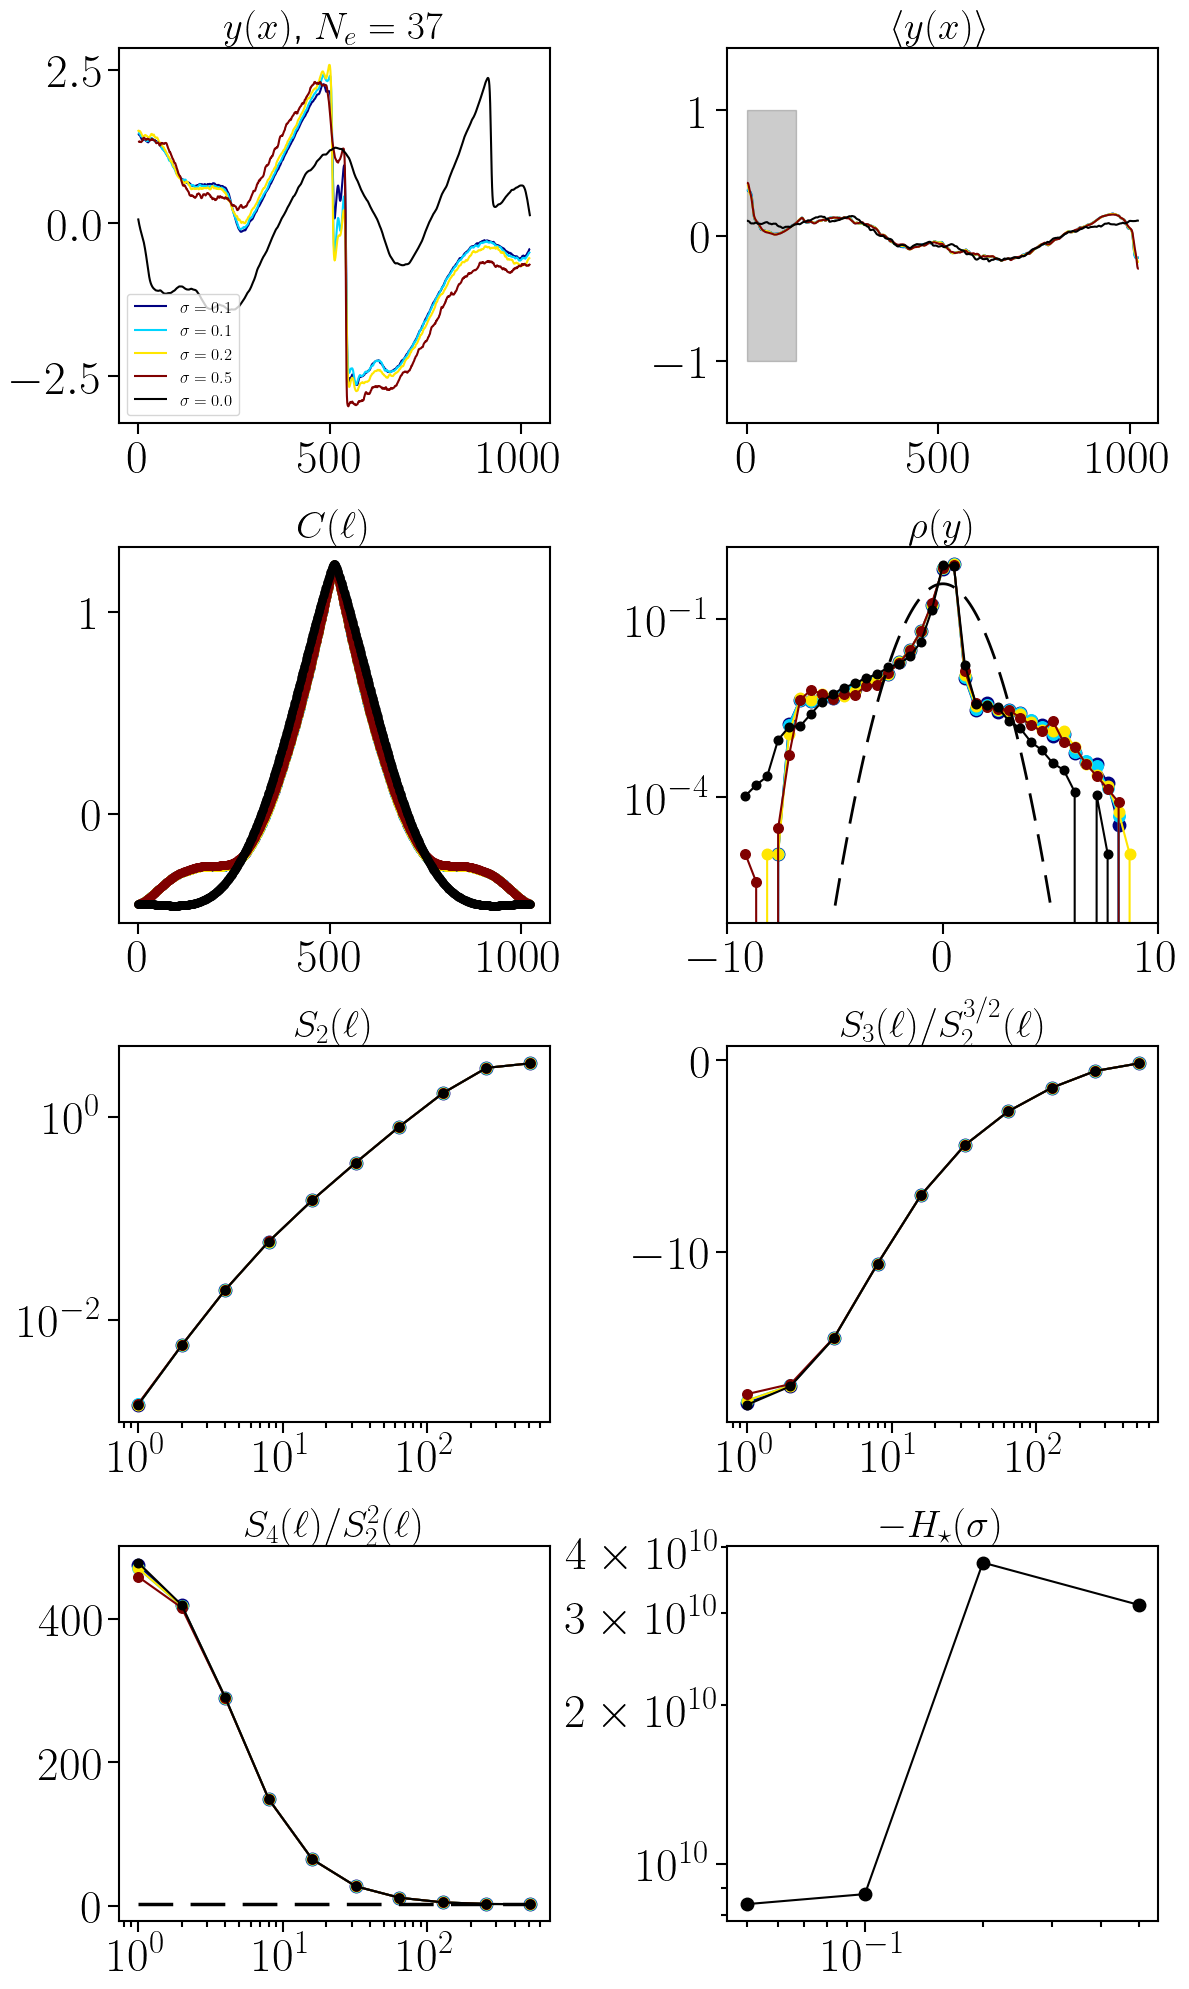

In [8]:
fig,ax=plt.subplots(4,2,figsize=(12,20))

np.random.seed(1)
ii=np.random.randint(Ne)
# ii=120
dash=[1,0]

# if sga==None:
#     fig_name = "figs/fig_"+moments[imom]+"_nta{:08d}_sigs_nwa{:08d}.pdf".format(Nta,nwa)
#     labels=[r"$\sigma={:.1f}$".format(sigmas[i]) for i in range(len(sigmas))]
#     Mx=sigmas
#     Mlab=r"$\sigma$"
# if Nta==None:
#     fig_name = "figs/fig_"+moments[imom]+"_nts_siga{:.2f}_nwa{:08d}.pdf".format(sga,nwa)
#     labels=[r"$N_t={:.0f}$".format(Nts[i]) for i in range(len(Nts))]
#     Mx=Nta
#     Mlab=r"$N_t$"
# if nwa==None:
#     fig_name = "figs/fig_"+moments[imom]+"_nta{:08d}_siga{:.2f}_nws.pdf".format(Nta,sga)
#     labels=[r"$N_w={:.0f}$".format(nwindo[i]) for i in range(len(nwindo))]
#     Mx=nwindo
#     Mlab=r"$N_w$"

fig_name = "figs/fig_"+moments[imom]+"_nts_sigs_nws.pdf"
labels=[r"$\sigma={:.1f}$".format(sigmas[i]) for i in range(len(sigmas))]
Mx=sigmas
Mlab=r"$\sigma$"

for i in range(lr+1):
    ax[0,0].plot(x,z[i][ii],'-',ms=9,c=c[i],dashes=dash,
                  label=labels[i]) 
    ax[0,1].plot(x,np.mean(z[i],axis=0),'-',ms=9,c=c[i],dashes=dash)
    ax[1,0].plot(x,c0[i],'-o',ms=5,c=c[i],dashes=dash)
    ax[1,1].plot(hisx/sig,sig*hist[i],'-o',ms=9-0.7*i,c=c[i],dashes=dash)
    ax[2,0].plot(x12,S[i],'-o',ms=9-0.7*i,c=c[i],dashes=dash)
    ax[2,1].plot(x12,G[i]/S[i]**1.5,'-o',ms=9-0.7*i,c=c[i],dashes=dash)
    ax[3,0].plot(x12,F[i]/S[i]**2,'-o',ms=9-0.7*i,c=c[i],dashes=dash)
    
ax[3,1].plot(Mx[:-1],-M[:-1],'o',ms=9,c='k',dashes=dash)
ax[0,1].fill_between([0,Nx/np.max(nwindo)],-1,1,color='k',alpha=0.2)
    
x11=x[1:Nx//2+1]
ax[3,0].plot(x12,3+0*x12,c='k',dashes=[10,5],lw=2.5)

ax[1,1].plot(xp,yp,dashes=[10,5],ms=10,c='k',lw=2)

# ax[0,0].set_ylim(-2.5,2.5)
ax[0,1].set_ylim(-1.5,1.5)
ax[1,1].set_yscale("log")
ax[2,0].set_yscale("log")
ax[3,1].set_yscale("log")

ax[2,0].set_xscale("log")
ax[2,1].set_xscale("log")
ax[3,0].set_xscale("log")
ax[3,1].set_xscale("log")

ax[1,1].set_xlim(-10,10)
# ax[3,0].set_ylim(-.1,1.0)
# ax[3,1].set_ylim(0,0.1)

ax[0,0].set_title(r"$y(x)$, $N_e={:}$".format(ii),fontsize=28)
ax[0,1].set_title(r"$\langle y(x)\rangle$",fontsize=28)
ax[1,0].set_title(r"$C(\ell)$",fontsize=28)
ax[1,1].set_title(r"$\rho(y)$",fontsize=28)
ax[2,0].set_title(r"$S_2(\ell)$",fontsize=28)
ax[2,1].set_title(r"$S_3(\ell)/S_2^{3/2}(\ell)$",fontsize=28)
ax[3,0].set_title(r"$S_4(\ell)/S_2^2(\ell)$",fontsize=28)
ax[3,1].set_title(r"$-H_\star($"+Mlab+"$)$",fontsize=28)

ax[0,0].legend(fontsize=12)
plt.tight_layout()

if os.path.exists("figs")==False:
    os.mkdir("figs")
plt.savefig(fig_name,dpi=300)
plt.show()

  0%|          | 0/5 [00:00<?, ?it/s]

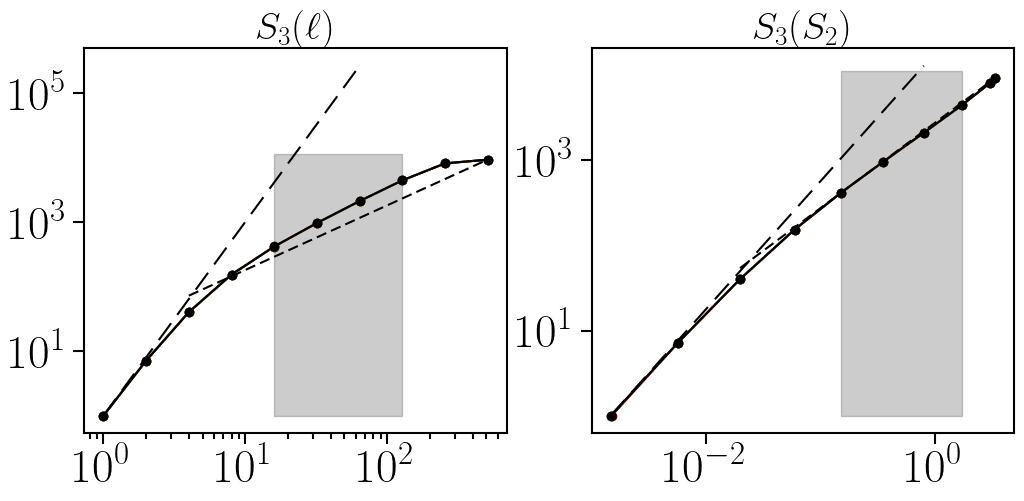

In [9]:
da=1/2
ells = ells.astype(int)

ps=np.arange(int(6/da))*da
fit_stf=np.zeros((len(Mx),len(ps)))
fit_ess=np.zeros((len(Mx),len(ps)))

ii=4
jj=7

ii2=4
jj2=7

base=2
pu=3
fig,ax=plt.subplots(1,2,figsize=(12,5))
m0=0
for j in tqdm(range(lr+1)):
    temp0=np.mean(SF(z[j],ells,base,True),axis=0)

    for i in range(1,len(ps)):
        temp=np.mean(SF(z[j],ells,ps[i],True),axis=0)
        fit_stf[j,i]=np.polyfit(np.log(ells[ii:jj]),np.log(temp[ii:jj]),1)[0]
        fit_ess[j,i]=np.polyfit(np.log(temp0[ii2:jj2]),np.log(temp[ii2:jj2]),1)[0]
        if ps[i]==pu:
            ax[0].plot(ells, (temp/temp[0]),'o-',c=c[j])
            ax[1].plot(temp0,(temp/temp[0]),'o-',c=c[j])
            m0=max(m0,np.max(temp/temp[0]))
    
ax[0].fill_between([ells[ii],ells[jj]],1,1.2*m0,color="k",alpha=0.2)
ax[1].fill_between([temp0[ii2],temp0[jj2]],1,1.2*m0,color="k",alpha=0.2)

ax[0].plot(ells[:-3],ells[:-3]**pu,dashes=[10,5],c='k')
ax[0].plot(ells[2:],(ells[2:]/ells[-1])*m0,dashes=[5,2.5],c='k')

ax[1].plot(temp0[:-3],(temp0[:-3]/temp0[0])**(pu/base),dashes=[10,5],c='k')
ax[1].plot(temp0[2:] ,(temp0[2:]/temp0[-1])*m0,dashes=[5,2.5],c='k')

for i in range(2):
    ax[i].set_yscale("log")
    ax[i].set_xscale("log")

ax[0].set_title(r"$S_{{ {:} }}(\ell)$".format(pu),fontsize=28)
ax[1].set_title(r"$S_{{ {:} }}(S_{{ {:} }})$".format(pu,base),fontsize=28)

plt.show()

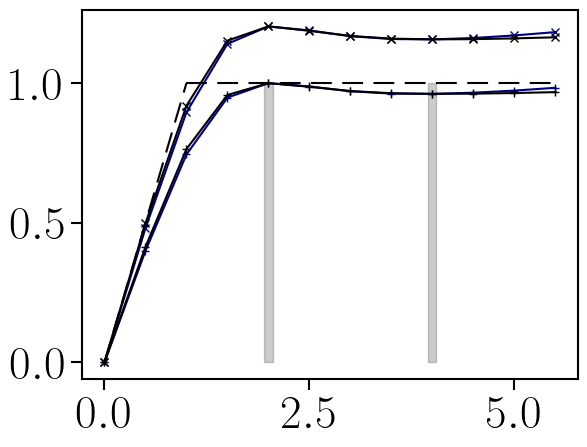

In [53]:

for i in range(lr+1):
    plt.plot(ps,fit_stf[i],'-x',c=c[i],ms=6)
    plt.plot(ps,fit_ess[i],'-+',c=c[i],ms=6)
    

plt.plot(ps[(ps<=1)],ps[(ps<=1)],dashes=[10,5],c='k')
plt.plot(ps[(ps>=1)],0*ps[(ps>=1)]+1,dashes=[10,5],c='k')
# plt.fill_between([2.95,3.05],0,1,color="k",alpha=0.2)
plt.fill_between([1.95,2.05],0,1,color="k",alpha=0.2)
plt.fill_between([3.95,4.05],0,1,color="k",alpha=0.2)

plt.show()